# Analytic IK for the Vega arm: `ssik` vs the bundled EAIK solver

Vega's 7-DOF arm has a **non-spherical wrist** (a *non-SRS* 7R chain), so no textbook closed-form 6R/7R solver applies. `prpl_kinematics` ships [`VegaArmIK`](../src/prpl_kinematics/robots/vega_ik.py), which works around this by locking two joints, grid-searching them, and running EAIK on the residual 5R chain.

[`ssik`](https://pypi.org/project/ssik/) (Personal Robotics Lab) solves exactly this non-SRS 7R class analytically. This notebook checks that `ssik` reaches Vega's targets and benchmarks it against `VegaArmIK`. The backend is selected with `make_vega(ik=...)`.

> Requires the optional extra: `pip install "prpl_kinematics[ssik]"` (`ssik` needs `numpy>=2`).

In [1]:
import time

import numpy as np

from prpl_kinematics.robots import make_vega

eaik = make_vega(ik="eaik")  # bundled lock-and-grid-search over EAIK
ssik = make_vega(ik="ssik")  # the ssik analytic solver
LEFT = [f"L_arm_j{i}" for i in range(1, 8)]
RIGHT = [f"R_arm_j{i}" for i in range(1, 8)]
print("left-arm IK:",
      type(eaik.manipulators['left'].ik).__name__, "(eaik) vs",
      type(ssik.manipulators['left'].ik).__name__, "(ssik)")

pybullet build time: Mar 13 2026 19:11:34


left-arm IK: VegaArmIK (eaik) vs SSIKSolver (ssik)


## Correctness: round-trip a known pose

Take a joint configuration, use its forward kinematics as the IK target, and solve from the home seed. We report how closely the solved configuration's FK matches the target (each solver returns the branch nearest the seed).

In [2]:
truth_q = [0.3, -0.4, 0.2, -1.0, 0.1, 0.6, -0.3]
for side, joints in [("left", LEFT), ("right", RIGHT)]:
    truth = {**dict(eaik.home), **{n: [v] for n, v in zip(joints, truth_q)}}
    for name, robot in [("VegaArmIK", eaik), ("ssik", ssik)]:
        m = robot.manipulators[side]
        target = robot.tree.forward_kinematics(m.ee_frame, truth)
        sol = m.ik.solve(target, robot.home)
        reached = robot.tree.forward_kinematics(m.ee_frame, sol)
        err = np.linalg.norm(np.asarray(reached.t) - np.asarray(target.t))
        print(f"{side:5s} {name:10s} position error = {err:.2e}")

left  VegaArmIK  position error = 1.55e-05


left  ssik       position error = 4.72e-16


right VegaArmIK  position error = 2.39e-05


right ssik       position error = 4.58e-16


## Benchmark: success rate, speed, accuracy

Sample random in-limit configurations, use their forward kinematics as targets, and solve each from the home seed with both backends.

In [3]:
rng = np.random.default_rng(0)
tree = eaik.tree
lower = np.array([tree.joint(n).lower_limits[0] for n in LEFT])
upper = np.array([tree.joint(n).upper_limits[0] for n in LEFT])
num_targets = 30
targets = []
for _ in range(num_targets):
    q = lower + (upper - lower) * rng.random(7)
    cfg = {**dict(eaik.home), **{n: [float(v)] for n, v in zip(LEFT, q)}}
    targets.append(tree.forward_kinematics("L_ee", cfg))


def benchmark(robot):
    """Success count, mean ms/solve, and worst position error over targets."""
    m = robot.manipulators["left"]
    solved, errors = 0, []
    start = time.perf_counter()
    for target in targets:
        sol = m.ik.solve(target, robot.home)
        if sol is None:
            continue
        reached = robot.tree.forward_kinematics("L_ee", sol)
        err = np.linalg.norm(np.asarray(reached.t) - np.asarray(target.t))
        if err < 1e-3:
            solved += 1
            errors.append(err)
    ms = 1e3 * (time.perf_counter() - start) / len(targets)
    return solved, ms, max(errors)


print(f"{'solver':12s}{'success':>10s}{'ms/solve':>12s}{'max pos err':>14s}")
for name, robot in [("VegaArmIK", eaik), ("ssik", ssik)]:
    ok, ms, mx = benchmark(robot)
    print(f"{name:12s}{ok:>7d}/{num_targets:<2d}{ms:>11.1f}{mx:>14.1e}")

solver         success    ms/solve   max pos err


VegaArmIK        30/30      354.8       8.9e-05


ssik             30/30      355.3       2.5e-15


`ssik` reaches every target at ~machine precision, far tighter than the grid-search EAIK (which sits near its `1e-4` tolerance), at comparable speed.

## Visual check

Drive both Vega arms to `ssik`-solved targets and render the result.

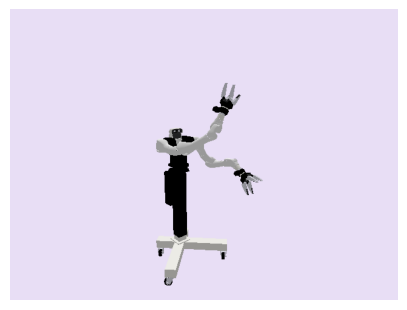

In [4]:
import matplotlib.pyplot as plt
import pybullet as p

from prpl_kinematics.visualization import (
    CameraParams, PyBulletRenderer, capture_image)

goal_q = {"left": [0.3, -0.4, 0.2, -1.0, 0.1, 0.6, -0.3],
          "right": [-0.3, 0.4, -0.2, -1.0, -0.1, 0.6, 0.3]}
config = dict(ssik.home)
for side, joints in [("left", LEFT), ("right", RIGHT)]:
    m = ssik.manipulators[side]
    truth = {**dict(ssik.home), **{n: [v] for n, v in zip(joints, goal_q[side])}}
    target = ssik.tree.forward_kinematics(m.ee_frame, truth)
    config.update(ssik.manipulators[side].ik.solve(target, ssik.home))

renderer = PyBulletRenderer(p.connect(p.DIRECT))
renderer.load(ssik.tree)
renderer.render(config)
camera = CameraParams(target=(0.4, 0.0, 1.0), distance=2.2, yaw=50.0,
                      pitch=-12.0, width=640, height=480)
image = capture_image(renderer.physics_client_id, camera)
plt.figure(figsize=(5, 4))
plt.axis("off")
plt.imshow(image)
plt.show()

## Takeaway

`ssik` solves Vega's non-SRS 7R arm analytically (with a short Newton refinement to close the joint-lock sweep), reaching targets at ~machine precision -- markedly tighter than the bundled grid-search EAIK, at comparable speed. Enable it with `make_vega(ik="ssik")`.